[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.2_what_happens_during_inference/lab.ipynb) [![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.2_what_happens_during_inference/lab.ipynb)

# Lab 0.2: What Happens During Inference

In this lab we build a minimal transformer and measure the difference between **prefill** and **decode**. You will see firsthand:

1. **Prefill** processes the entire prompt in one parallel forward pass
2. **Decode** generates tokens one at a time, and without caching, must re-read the full sequence each step
3. The resulting cost asymmetry: decode dominates total latency

We intentionally avoid the KV cache here (that is Module 0.3) so you can feel the pain it solves.

In [11]:
# Install dependencies (quiet mode)
!pip install -q torch matplotlib numpy

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import time
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
print(f"PyTorch {torch.__version__} | Device: cpu")

PyTorch 2.6.0+cu124 | Device: cpu


## Building a Minimal Transformer

We create a tiny transformer that has the **same structure** as production models (Llama, Mistral) but with fewer layers and smaller dimensions so it runs on CPU in seconds.

| Parameter | Our Model | Llama 3.1 8B |
|-----------|-----------|--------------|
| Hidden dim | 256 | 4096 |
| Layers | 4 | 32 |
| Heads | 4 | 32 |
| Vocab | 1000 | 128k |

The architecture is identical: embedding → N × (attention + MLP) → LM head. Only the scale differs.

In [12]:
class MiniTransformer(nn.Module):
    """A minimal transformer with the same structure as Llama/Mistral."""

    def __init__(self, vocab_size=1000, hidden=512, n_layers=8, n_heads=8, intermediate=1024):
        super().__init__()
        # Token embedding: maps token IDs to dense vectors (same as in 0.1)
        self.embedding = nn.Embedding(vocab_size, hidden)

        # Transformer layers: each has attention + feed-forward MLP
        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(nn.ModuleDict({
                # Multi-head self-attention (Q, K, V projections inside)
                "attention": nn.MultiheadAttention(hidden, n_heads, batch_first=True),
                # Layer norm before attention (pre-norm, like modern LLMs)
                "norm1": nn.LayerNorm(hidden),
                # Feed-forward MLP: hidden -> 4x hidden -> hidden
                "mlp": nn.Sequential(
                    nn.Linear(hidden, intermediate),
                    nn.GELU(),
                    nn.Linear(intermediate, hidden),
                ),
                # Layer norm before MLP
                "norm2": nn.LayerNorm(hidden),
            }))

        # Final layer norm + LM head: projects back to vocab for next-token prediction
        self.final_norm = nn.LayerNorm(hidden)
        self.lm_head = nn.Linear(hidden, vocab_size, bias=False)

    def forward(self, input_ids):
        # input_ids shape: (batch, seq_len)
        # Convert token IDs to embeddings
        x = self.embedding(input_ids)  # (batch, seq_len, hidden)

        # Create causal mask so each token only attends to previous tokens
        seq_len = input_ids.shape[1]
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len)

        # Pass through each transformer layer
        for layer in self.layers:
            # Pre-norm + self-attention + residual connection
            normed = layer["norm1"](x)
            attn_out, _ = layer["attention"](normed, normed, normed, attn_mask=causal_mask)
            x = x + attn_out  # Residual connection

            # Pre-norm + MLP + residual connection
            normed = layer["norm2"](x)
            x = x + layer["mlp"](normed)  # Residual connection

        # Final norm + project to vocabulary logits
        x = self.final_norm(x)
        logits = self.lm_head(x)  # (batch, seq_len, vocab_size)
        return logits


# Instantiate the model
model = MiniTransformer()
model.eval()  # Inference mode (no dropout)

# Count parameters to show this is tiny
n_params = sum(p.numel() for p in model.parameters())
print(f"MiniTransformer: {n_params:,} parameters ({n_params/1e6:.1f}M)")
print(f"Structure: embedding -> 8 layers x (attention + MLP) -> lm_head")

MiniTransformer: 17,847,296 parameters (17.8M)
Structure: embedding -> 8 layers x (attention + MLP) -> lm_head


## Prefill: Processing the Full Prompt

When you send a prompt to an LLM, the model processes **all prompt tokens at once** in a single forward pass. This is the **prefill** phase.

Why is this fast? Because all tokens are independent inputs to the same matrix multiplications. The GPU (or CPU) computes them in parallel, just like multiplying a matrix by a tall matrix instead of one vector at a time.

The time it takes to complete prefill determines **TTFT** (Time to First Token): how long the user waits before seeing any output.

In [13]:
def prefill(model, prompt_ids):
    """Process ALL prompt tokens in a single forward pass.
    This is fast because all tokens are computed in parallel."""
    with torch.no_grad():
        logits = model(prompt_ids)  # (1, seq_len, vocab)
    return logits


# Measure prefill time for different prompt lengths
prompt_lengths = [32, 64, 128, 256, 512, 1000]
prefill_times_ms = []

for length in prompt_lengths:
    # Create a random prompt of the given length
    prompt = torch.randint(0, 1000, (1, length))

    # Warm-up run (first run is always slower due to memory allocation)
    _ = prefill(model, prompt)

    # Timed run: average over 5 iterations for stability
    times = []
    for _ in range(5):
        start = time.perf_counter()
        _ = prefill(model, prompt)
        times.append((time.perf_counter() - start) * 1000)  # Convert to ms

    avg_ms = np.mean(times)
    prefill_times_ms.append(avg_ms)
    print(f"Prompt length {length:>4} tokens -> prefill: {avg_ms:.2f} ms")

print(f"\n512 tokens takes {prefill_times_ms[-1]/prefill_times_ms[0]:.1f}x longer than 32 tokens")
print("(Scales roughly quadratically due to attention's O(n^2) cost)")

Prompt length   32 tokens -> prefill: 13.45 ms
Prompt length   64 tokens -> prefill: 13.22 ms
Prompt length  128 tokens -> prefill: 17.67 ms
Prompt length  256 tokens -> prefill: 27.42 ms
Prompt length  512 tokens -> prefill: 51.36 ms
Prompt length 1000 tokens -> prefill: 114.69 ms

512 tokens takes 8.5x longer than 32 tokens
(Scales roughly quadratically due to attention's O(n^2) cost)


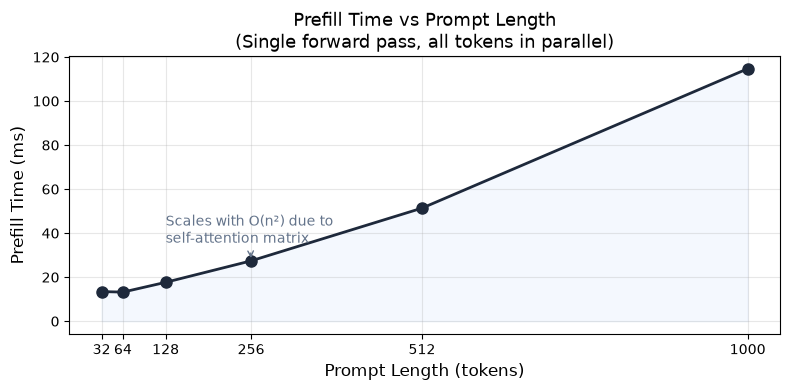

Saved: prefill_scaling.png


In [14]:
# Plot prefill time vs prompt length
fig, ax = plt.subplots(figsize=(8, 4))

# Line chart with markers
ax.plot(prompt_lengths, prefill_times_ms, 'o-', color='#1e293b', linewidth=2, markersize=8)

# Fill area under the curve with pastel blue
ax.fill_between(prompt_lengths, prefill_times_ms, alpha=0.3, color='#dbeafe')

# Labels and formatting
ax.set_xlabel("Prompt Length (tokens)", fontsize=12)
ax.set_ylabel("Prefill Time (ms)", fontsize=12)
ax.set_title("Prefill Time vs Prompt Length\n(Single forward pass, all tokens in parallel)", fontsize=13)
ax.set_xticks(prompt_lengths)
ax.grid(True, alpha=0.3)

# Annotate scaling behavior
ax.annotate("Scales with O(n\u00b2) due to\nself-attention matrix",
            xy=(256, prefill_times_ms[3]), xytext=(128, prefill_times_ms[3]*1.3),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#64748b'),
            color='#64748b')

plt.tight_layout()
plt.savefig("prefill_scaling.png", dpi=100, bbox_inches='tight')
plt.show()
print("Saved: prefill_scaling.png")

## Decode: Generating One Token at a Time

After prefill, the model enters the **decode** phase. It takes the logits from the last position, picks a token, appends it to the sequence, and runs the full model again to get the next token.

This is inherently sequential: token N+1 depends on token N.

**Critical insight**: In this naive implementation (no KV cache), each decode step re-processes the **entire** sequence from scratch. As the sequence grows, each step gets slower. This is the problem that the KV cache (Module 0.3) solves.

In [15]:
def generate(model, prompt_ids, num_tokens=1000):
    """Generate tokens one at a time WITHOUT a KV cache.
    Each step re-processes the full sequence (intentionally naive)."""

    # --- Step 1: Prefill --- process entire prompt at once
    all_ids = prompt_ids.clone()
    start_prefill = time.perf_counter()
    logits = model(all_ids)
    prefill_time = (time.perf_counter() - start_prefill) * 1000  # ms

    # --- Step 2: Decode --- generate tokens one at a time
    token_times = []
    for i in tqdm(range(num_tokens), desc="Decoding"):
        start = time.perf_counter()

        # Take the last token's logits, pick the most likely next token (greedy)
        next_token = logits[0, -1, :].argmax(dim=-1, keepdim=True).unsqueeze(0)

        # Append the new token to the full sequence
        all_ids = torch.cat([all_ids, next_token], dim=1)

        # Forward pass with the FULL sequence (no caching!)
        # This means step 1 processes prompt+1 tokens,
        # step 2 processes prompt+2 tokens, etc.
        logits = model(all_ids)

        elapsed = (time.perf_counter() - start) * 1000  # ms
        token_times.append(elapsed)

    return all_ids, prefill_time, token_times


# Generate 50 tokens from a 64-token prompt
prompt = torch.randint(0, 1000, (1, 64))
output_ids, prefill_ms, decode_times = generate(model, prompt, num_tokens=1000)

print(f"Prompt: 64 tokens | Generated: 50 tokens | Total: {output_ids.shape[1]} tokens")
print(f"Prefill: {prefill_ms:.1f} ms (all 64 tokens at once)")
print(f"Decode:  {sum(decode_times):.1f} ms total ({np.mean(decode_times):.1f} ms/token avg)")
print(f"\nFirst decode step: {decode_times[0]:.1f} ms (processes 65 tokens)")
print(f"Last decode step:  {decode_times[-1]:.1f} ms (processes 114 tokens)")
print(f"Slowdown: {decode_times[-1]/decode_times[0]:.2f}x (because sequence grows each step)")

Decoding:   0%|          | 0/1000 [00:00<?, ?it/s]

Decoding: 100%|██████████| 1000/1000 [01:08<00:00, 14.51it/s]

Prompt: 64 tokens | Generated: 50 tokens | Total: 1064 tokens
Prefill: 22.6 ms (all 64 tokens at once)
Decode:  68491.7 ms total (68.5 ms/token avg)

First decode step: 23.1 ms (processes 65 tokens)
Last decode step:  131.9 ms (processes 114 tokens)
Slowdown: 5.71x (because sequence grows each step)


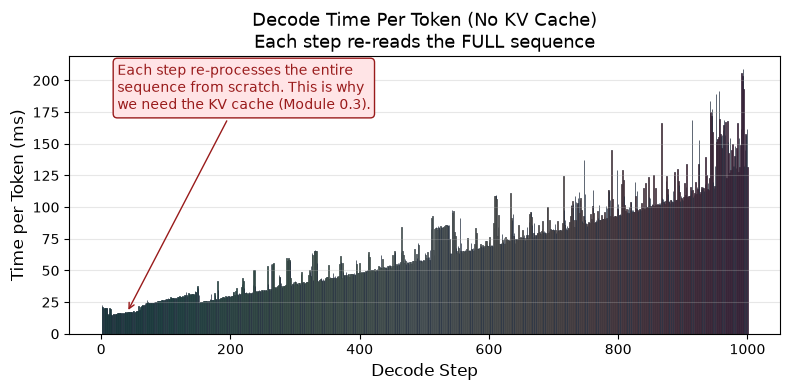

Saved: decode_per_token.png


In [16]:
# Plot decode time per token (shows INCREASING cost)
fig, ax = plt.subplots(figsize=(8, 4))

steps = range(1, len(decode_times) + 1)

# Bar chart colored with gradient from green (fast) to rose (slow)
colors = [plt.cm.RdYlGn(1.0 - i/len(decode_times)) for i in range(len(decode_times))]
ax.bar(steps, decode_times, color=colors, edgecolor='#1e293b', linewidth=0.5)

# Labels
ax.set_xlabel("Decode Step", fontsize=12)
ax.set_ylabel("Time per Token (ms)", fontsize=12)
ax.set_title("Decode Time Per Token (No KV Cache)\nEach step re-reads the FULL sequence", fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Annotation explaining the growth
ax.annotate(
    "Each step re-processes the entire\nsequence from scratch. This is why\nwe need the KV cache (Module 0.3).",
    xy=(40, decode_times[39]), xytext=(25, max(decode_times)*0.85),
    fontsize=10, color='#991b1b',
    arrowprops=dict(arrowstyle='->', color='#991b1b'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe4e6', edgecolor='#991b1b')
)

plt.tight_layout()
plt.savefig("decode_per_token.png", dpi=100, bbox_inches='tight')
plt.show()
print("Saved: decode_per_token.png")

## Prefill vs Decode: The Cost Asymmetry

Now let us compare the two phases side by side. Even though prefill processes 64 tokens and decode generates only 50, decode dominates the total time because it runs the model 50 separate times (once per token), each time over an increasingly long sequence.

⚠️  Running on CPU: prefill times are inflated. On GPU, prefill would be 10-100x faster.
    The important pattern: decode gets slower per step, prefill scales better.


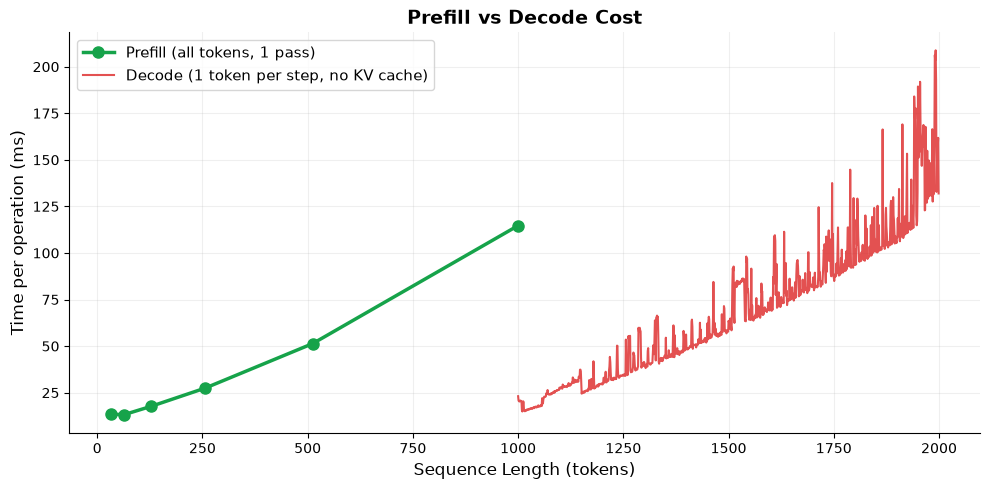

Prefill 1000 tokens:  114.7 ms (once)
Decode  1000 tokens: 68492 ms total
Ratio: decode is 597x more expensive


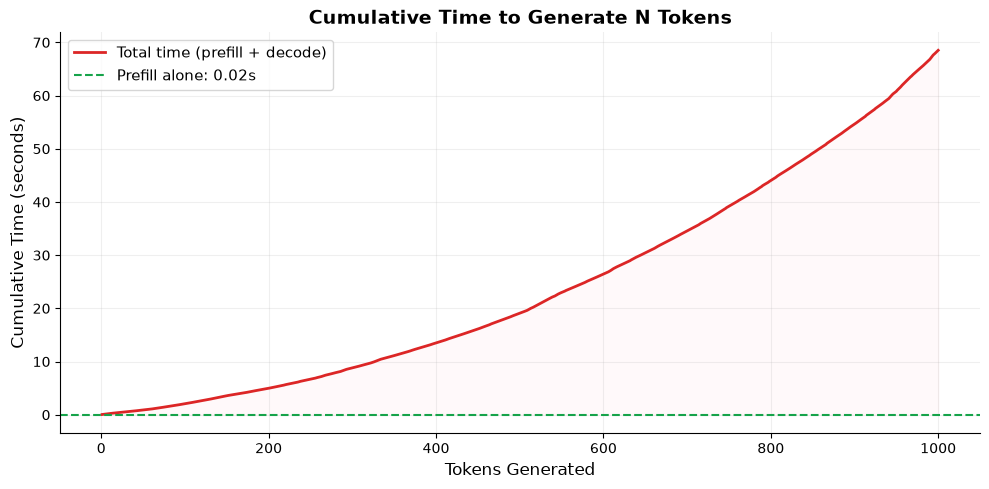

Time to generate 1000 tokens: 68.5 seconds
Prefill was only 0.0% of total time


In [26]:
# NOTE: On CPU, prefill appears slow because CPU cannot parallelize matrix multiplications
# efficiently. On GPU, prefill is MUCH faster (10-100x) because GPUs excel at parallel math.
# The key insight remains: decode cost grows with sequence length, prefill does not grow per-token.
print("⚠️  Running on CPU: prefill times are inflated. On GPU, prefill would be 10-100x faster.")
print("    The important pattern: decode gets slower per step, prefill scales better.")

# --- Prefill vs Decode: Line Chart Comparison ---

fig, ax = plt.subplots(figsize=(10, 5))

# Prefill: time to process N tokens in ONE pass
ax.plot(prompt_lengths, prefill_times_ms, "o-", color="#16a34a", linewidth=2.5,
        markersize=8, label="Prefill (all tokens, 1 pass)", zorder=3)

# Decode: time per step as sequence grows (no KV cache)
decode_seq_lengths = [prompt_lengths[-1] + i for i in range(len(decode_times))]
ax.plot(decode_seq_lengths, decode_times, "-", color="#dc2626", linewidth=1.5,
        alpha=0.8, label="Decode (1 token per step, no KV cache)")

# Clean formatting
ax.set_xlabel("Sequence Length (tokens)", fontsize=12)
ax.set_ylabel("Time per operation (ms)", fontsize=12)
ax.set_title("Prefill vs Decode Cost", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Summary stats
total_decode = sum(decode_times)
print(f"Prefill {prompt_lengths[-1]} tokens:  {prefill_times_ms[-1]:.1f} ms (once)")
print(f"Decode  {len(decode_times)} tokens: {total_decode:.0f} ms total")
print(f"Ratio: decode is {total_decode / prefill_times_ms[-1]:.0f}x more expensive")


# --- Cumulative time to generate N tokens ---
cumulative_ms = np.cumsum(decode_times)  # Running total of decode time
cumulative_with_prefill = prefill_ms + cumulative_ms  # Include prefill

fig, ax = plt.subplots(figsize=(10, 5))

# Plot cumulative time
ax.plot(range(1, len(decode_times)+1), cumulative_with_prefill / 1000, "-", 
        color="#dc2626", linewidth=2, label="Total time (prefill + decode)")

# Prefill baseline (flat line showing prefill cost)
ax.axhline(y=prefill_ms/1000, color="#16a34a", linestyle="--", linewidth=1.5,
           label=f"Prefill alone: {prefill_ms/1000:.2f}s")

# Fill the decode area
ax.fill_between(range(1, len(decode_times)+1), prefill_ms/1000, 
                cumulative_with_prefill/1000, alpha=0.2, color="#ffe4e6")

ax.set_xlabel("Tokens Generated", fontsize=12)
ax.set_ylabel("Cumulative Time (seconds)", fontsize=12)
ax.set_title("Cumulative Time to Generate N Tokens", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Time to generate 1000 tokens: {cumulative_with_prefill[-1]/1000:.1f} seconds")
print(f"Prefill was only {prefill_ms/cumulative_with_prefill[-1]*100:.1f}% of total time")


## Metrics from Our Model

We can now compute the four key inference metrics directly from our measurements. These are the same metrics used to evaluate production LLM serving systems.

INFERENCE METRICS
  TTFT (Time to First Token):  22.6 ms
  ITL  (Inter-Token Latency):  68.5 ms/token
  Total Latency:               68.5 seconds
  Throughput:                   14.6 tokens/sec


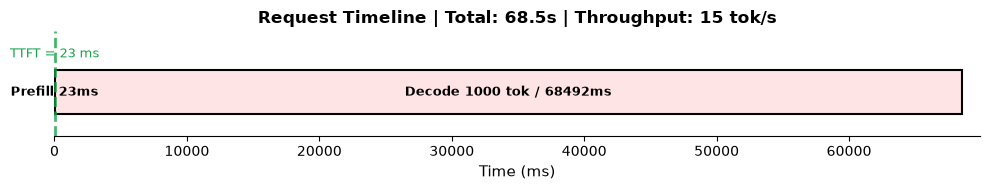

In [28]:
# --- Compute the four key inference metrics ---
ttft = prefill_ms                                    # Time to First Token = prefill time
itl = np.mean(decode_times)                          # Inter-Token Latency = avg decode step
total_latency = prefill_ms + sum(decode_times)       # End-to-end latency
throughput = len(decode_times) / (sum(decode_times) / 1000)  # tokens/second

print("=" * 50)
print("INFERENCE METRICS")
print("=" * 50)
print(f"  TTFT (Time to First Token):  {ttft:.1f} ms")
print(f"  ITL  (Inter-Token Latency):  {itl:.1f} ms/token")
print(f"  Total Latency:               {total_latency/1000:.1f} seconds")
print(f"  Throughput:                   {throughput:.1f} tokens/sec")
print("=" * 50)

# --- Clean Gantt-style timeline (two blocks only) ---
fig, ax = plt.subplots(figsize=(10, 2))

total_decode = sum(decode_times)

# Two simple bars: prefill (green) and decode (rose)
ax.barh(0, prefill_ms, left=0, color="#dcfce7", edgecolor="#000", linewidth=1.5, height=0.5)
ax.barh(0, total_decode, left=prefill_ms, color="#ffe4e6", edgecolor="#000", linewidth=1.5, height=0.5)

# Labels inside the bars (only if they fit)
ax.text(prefill_ms / 2, 0, f"Prefill {prefill_ms:.0f}ms",
        ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(prefill_ms + total_decode / 2, 0, f"Decode {len(decode_times)} tok / {total_decode:.0f}ms",
        ha="center", va="center", fontsize=9, fontweight="bold")

# TTFT marker
ax.axvline(x=prefill_ms, color="#16a34a", linestyle="--", linewidth=2, alpha=0.8)
ax.text(prefill_ms, 0.4, f"TTFT = {ttft:.0f} ms", ha="center", fontsize=9, color="#16a34a")

# Clean formatting
ax.set_xlim(0, total_latency * 1.02)
ax.set_ylim(-0.5, 0.7)
ax.set_yticks([])
ax.set_xlabel("Time (ms)", fontsize=11)
ax.set_title(f"Request Timeline | Total: {total_latency/1000:.1f}s | Throughput: {throughput:.0f} tok/s",
             fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()


## Key Takeaways

1. **Prefill is ONE parallel operation.** All prompt tokens are processed simultaneously in a single matrix multiplication. This is why TTFT scales moderately with prompt length.

2. **Decode without caching re-reads the full sequence each step.** Our naive implementation shows time-per-token *increasing* as the sequence grows. Step 50 is significantly slower than step 1.

3. **Module 0.3 introduces the KV cache**, which fixes the "re-read everything" problem by storing intermediate attention results. Each decode step then only processes the *new* token.

4. **But even with caching, decode must still read all model weights each step.** This is the bandwidth wall you will study in Chapter 1. The KV cache eliminates redundant *input* computation, but every token still requires a full pass through all model parameters.

5. **The cost asymmetry is fundamental.** Prefill is compute-bound (big parallel matmuls). Decode is memory-bandwidth-bound (reading weights for one token at a time). Optimizing LLM inference means addressing both regimes differently.